# Stage 06 — Neighbourhood integration of Locomizer response, PM₂.₅ context, and CAFEIN route exposure

## Research purpose

This notebook is the first **integration stage** of the workflow.

It combines:

1. **observed Locomizer H3 footfall change** from Stage 05;
2. **regional PM₂.₅ event context** from FMI monitoring stations;
3. **CAFEIN neighbourhood geography**;
4. **Stage 03 walking-route exposure** for the sampled OD pairs; and
5. **Stage 04 cycling route alternatives to Otaniemi**, including the trade-off between exposure reduction and additional travel time.

The central question is:

> **Where does activity persist when regional air quality worsens, and where do the sampled CAFEIN routes suggest that lower-exposure mobility alternatives are more or less costly?**

## Important scope limitations

This notebook deliberately avoids overclaiming.

- FMI PM₂.₅ here is a **regional station-network context**, not an H3-specific pollution surface.
- Locomizer data describe **cell-level presence / footfall**, not individual trajectories.
- Stage 03 contains only a small set of candidate walking OD pairs.
- Stage 04 compares cycling routes **to Otaniemi/Aalto** for a selected set of origins.
- Therefore the route metrics are **sampled mobility-alternative indicators**, not complete measures of every resident's exposure or accessibility.

The output is a neighbourhood-level exploratory dataset that can later be expanded when archived ENFUSER or another gridded historical PM₂.₅ surface becomes available.


## 1. Imports and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import cafein.sampledata.helsinki as helsinki

# -------------------------------------------------------------------
# Project root
# -------------------------------------------------------------------
PROJECT_ROOT = Path("/scratch/project_2010417")

# Stage 05 output
STAGE05_DIR_CANDIDATES = [
    Path("../outputs/v3/05_locomizer_station_pm25"),
    PROJECT_ROOT / "paper3" / "outputs" / "v3" / "05_locomizer_station_pm25",
]

# Stage 03 output
STAGE03_DIR_CANDIDATES = [
    Path("../outputs/v2/03_candidate_walking_route_pm25_exposure"),
    PROJECT_ROOT / "paper3" / "outputs" / "v2" / "03_candidate_walking_route_pm25_exposure",
]

# Stage 04 output
STAGE04_DIR_CANDIDATES = [
    Path("../outputs/v2/04_cycling_exposure_to_otaniemi"),
    PROJECT_ROOT / "paper3" / "outputs" / "v2" / "04_cycling_exposure_to_otaniemi",
]

# Stage 00 PM2.5 products
PM25_DERIVED_DIR = (
    PROJECT_ROOT
    / "paper3"
    / "airqualityontario22-25"
    / "HMA_pm25"
    / "derived"
)

PM25_CANDIDATE_PAIRS = (
    PM25_DERIVED_DIR
    / "hma_pm25_same_hour_candidate_pairs.csv"
)

OUTPUT_DIR = Path("../outputs/v3/06_neighbourhood_integration")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------
# Interpretation thresholds
# -------------------------------------------------------------------
FOOTFALL_STABLE_THRESHOLD_PCT = 5.0

# Exploratory threshold for a relatively low additional cycling-time cost.
# Change this in sensitivity analysis rather than treating it as a universal rule.
LOW_EXTRA_TIME_MIN = 5.0

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/06_neighbourhood_integration


## 2. Helper: find outputs from earlier stages

The CSC working directory can vary depending on where the notebook is launched.

This helper searches the expected output folders rather than assuming one exact relative path.


In [2]:
def first_existing_file(
    directory_candidates,
    filename,
    required=True,
):
    checked = []

    for directory in directory_candidates:
        path = directory / filename
        checked.append(path)

        if path.exists():
            print("Using:", path.resolve())
            return path

    if required:
        raise FileNotFoundError(
            "Could not find the required file. Checked:\n"
            + "\n".join(str(p) for p in checked)
        )

    print(
        "Optional file not found:",
        filename,
    )
    return None


## 3. Locate Stage 05, Stage 03, and Stage 04 products

In [3]:
stage05_gpkg = first_existing_file(
    STAGE05_DIR_CANDIDATES,
    "locomizer_two_time_station_pm25_context.gpkg",
    required=True,
)

stage05_summary_csv = first_existing_file(
    STAGE05_DIR_CANDIDATES,
    "locomizer_pm25_two_time_summary.csv",
    required=True,
)

stage03_csv = first_existing_file(
    STAGE03_DIR_CANDIDATES,
    "stage03_cafein_v2_route_exposure.csv",
    required=False,
)

stage04_csv = first_existing_file(
    STAGE04_DIR_CANDIDATES,
    "stage04_cafein_v2_fastest_vs_exposure_weighted.csv",
    required=False,
)


Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/05_locomizer_station_pm25/locomizer_two_time_station_pm25_context.gpkg
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/05_locomizer_station_pm25/locomizer_pm25_two_time_summary.csv
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v2/03_candidate_walking_route_pm25_exposure/stage03_cafein_v2_route_exposure.csv
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v2/04_cycling_exposure_to_otaniemi/stage04_cafein_v2_fastest_vs_exposure_weighted.csv


## 4. Load CAFEIN neighbourhood geography

In [4]:
units = gpd.read_file(
    helsinki.mobility.neighbourhoods
)

units["unit_id"] = (
    units["Neighbourhood_unit_ID"]
    .astype("Int64")
)

neighbourhoods = units[
    [
        "unit_id",
        "Neighbourhood_name",
        "Municipality_name",
        "geometry",
    ]
].copy()

print("Neighbourhoods:", len(neighbourhoods))
print("CRS:", neighbourhoods.crs)

display(neighbourhoods.head())


Neighbourhoods: 298
CRS: EPSG:3067


,unit_id,Neighbourhood_name,Municipality_name,geometry
0,491011111,Pohjois-Leppävaara,Espoo,"MULTIPOLYGON (((379595.15 6678747.999, 379562...."
1,491011112,Etelä-Leppävaara,Espoo,"MULTIPOLYGON (((379029.254 6677829.657, 379007..."
2,491011113,Mäkkylä,Espoo,"MULTIPOLYGON (((380257.535 6678941.217, 380259..."
3,491011114,Lintukorpi,Espoo,"MULTIPOLYGON (((379115.695 6679654.899, 379115..."
4,491011115,Lintulaakso,Espoo,"MULTIPOLYGON (((380218.977 6679301.685, 380254..."


## 5. Load Stage 05 H3 footfall-change results

Stage 05 already contains:

- `footfall_A`
- `footfall_B`
- `delta_footfall`
- `pct_change_footfall`
- regional PM₂.₅ context
- response classification

The H3 geometries are used here to assign each small cell to a CAFEIN neighbourhood.


In [5]:
h3_change = gpd.read_file(
    stage05_gpkg,
    layer="h3_footfall_pm25_context",
)

print("Stage 05 H3 cells:", len(h3_change))
print("CRS:", h3_change.crs)

expected_stage05 = {
    "CODE",
    "footfall_A",
    "footfall_B",
    "delta_footfall",
    "pct_change_footfall",
    "regional_pm25_A_median",
    "regional_pm25_B_median",
    "regional_delta_pm25_median",
}

missing = expected_stage05.difference(
    h3_change.columns
)

if missing:
    raise ValueError(
        "Stage 05 is missing expected columns: "
        + ", ".join(sorted(missing))
    )

display(h3_change.head())


Stage 05 H3 cells: 4873
CRS: EPSG:4326


,CODE,footfall_A,footfall_B,delta_footfall,pct_change_footfall,regional_pm25_A_median,regional_pm25_B_median,regional_delta_pm25_median,response_class,geometry
0,8a08996d4c67fff,1,3,2,200.0,9.6,6.75,-2.85,footfall increased while regional PM2.5 improved,"POLYGON ((24.81277 60.26544, 24.81357 60.265, ..."
1,8a1126d3381ffff,5,5,0,0.0,9.6,6.75,-2.85,footfall stable while regional PM2.5 improved,"POLYGON ((24.93321 60.16945, 24.93401 60.16901..."
2,8a1126d0e277fff,1,1,0,0.0,9.6,6.75,-2.85,footfall stable while regional PM2.5 improved,"POLYGON ((25.03799 60.23481, 25.03879 60.23437..."
3,8a08996a8797fff,3,3,0,0.0,9.6,6.75,-2.85,footfall stable while regional PM2.5 improved,"POLYGON ((24.71006 60.23679, 24.71086 60.23635..."
4,8a1126d2922ffff,2,6,4,200.0,9.6,6.75,-2.85,footfall increased while regional PM2.5 improved,"POLYGON ((24.9754 60.28421, 24.9762 60.28377, ..."


## 6. Assign H3 cells to CAFEIN neighbourhoods

Because H3 resolution-10 cells are small relative to the CAFEIN neighbourhood units, the default exploratory assignment uses each H3 cell's **representative point**.

This avoids duplicating an H3 cell across multiple neighbourhoods.

For a final sensitivity analysis, an area-weighted H3-to-neighbourhood overlay could be compared against this centroid/representative-point assignment.


In [6]:
h3_for_join = h3_change.to_crs(
    neighbourhoods.crs
).copy()

h3_points = h3_for_join.copy()
h3_points["geometry"] = (
    h3_points.geometry.representative_point()
)

h3_joined = gpd.sjoin(
    h3_points,
    neighbourhoods,
    predicate="within",
    how="left",
)

matched = h3_joined["unit_id"].notna().sum()

print(
    f"Matched H3 cells: {matched:,} / {len(h3_joined):,} "
    f"({matched / len(h3_joined):.1%})"
)

display(
    h3_joined[
        [
            "CODE",
            "unit_id",
            "Neighbourhood_name",
            "Municipality_name",
            "footfall_A",
            "footfall_B",
            "pct_change_footfall",
        ]
    ].head()
)


Matched H3 cells: 4,873 / 4,873 (100.0%)


,CODE,unit_id,Neighbourhood_name,Municipality_name,footfall_A,footfall_B,pct_change_footfall
0,8a08996d4c67fff,921014000,Varisto,Vantaa,1,3,200.0
1,8a1126d3381ffff,911103040,Kamppi,Helsinki,5,5,0.0
2,8a1126d0e277fff,915501362,Latokartano,Helsinki,1,1,0.0
3,8a08996a8797fff,496063632,Järvenperä,Espoo,3,3,0.0
4,8a1126d2922ffff,923051000,Pakkala,Vantaa,2,6,200.0


## 7. Aggregate observed footfall response to neighbourhood level

Two complementary measures are retained:

### A. Change in summed observed cell activity

\[
100 \times
\frac{\sum F_B - \sum F_A}
{\sum F_A}
\]

### B. Distribution of H3-level responses

For each neighbourhood:

- share of cells with footfall decrease;
- share broadly stable;
- share with footfall increase.

This keeps the analysis from relying on a single aggregate percentage.


In [7]:
def footfall_class(pct):
    if pd.isna(pct):
        return "missing"

    if pct < -FOOTFALL_STABLE_THRESHOLD_PCT:
        return "decreased"

    if pct > FOOTFALL_STABLE_THRESHOLD_PCT:
        return "increased"

    return "stable"

h3_joined["footfall_class_simple"] = (
    h3_joined["pct_change_footfall"]
    .map(footfall_class)
)

matched_h3 = h3_joined.loc[
    h3_joined["unit_id"].notna()
].copy()

agg_base = (
    matched_h3
    .groupby(
        [
            "unit_id",
            "Neighbourhood_name",
            "Municipality_name",
        ],
        as_index=False,
    )
    .agg(
        n_h3_cells=("CODE", "nunique"),
        footfall_A_sum=("footfall_A", "sum"),
        footfall_B_sum=("footfall_B", "sum"),
        median_h3_pct_change=(
            "pct_change_footfall",
            "median",
        ),
        mean_h3_pct_change=(
            "pct_change_footfall",
            "mean",
        ),
        regional_pm25_A_median=(
            "regional_pm25_A_median",
            "first",
        ),
        regional_pm25_B_median=(
            "regional_pm25_B_median",
            "first",
        ),
        regional_delta_pm25_median=(
            "regional_delta_pm25_median",
            "first",
        ),
    )
)

agg_base["footfall_sum_pct_change"] = np.where(
    agg_base["footfall_A_sum"] > 0,
    100
    * (
        agg_base["footfall_B_sum"]
        - agg_base["footfall_A_sum"]
    )
    / agg_base["footfall_A_sum"],
    np.nan,
)

class_counts = (
    matched_h3
    .pivot_table(
        index="unit_id",
        columns="footfall_class_simple",
        values="CODE",
        aggfunc="nunique",
        fill_value=0,
    )
    .reset_index()
)

for col in ["decreased", "stable", "increased"]:
    if col not in class_counts.columns:
        class_counts[col] = 0

class_counts = class_counts.rename(
    columns={
        "decreased": "n_cells_decreased",
        "stable": "n_cells_stable",
        "increased": "n_cells_increased",
    }
)

neighbourhood_response = agg_base.merge(
    class_counts[
        [
            "unit_id",
            "n_cells_decreased",
            "n_cells_stable",
            "n_cells_increased",
        ]
    ],
    on="unit_id",
    how="left",
)

for name in [
    "decreased",
    "stable",
    "increased",
]:
    neighbourhood_response[
        f"share_cells_{name}"
    ] = (
        neighbourhood_response[
            f"n_cells_{name}"
        ]
        / neighbourhood_response["n_h3_cells"]
    )

display(
    neighbourhood_response.sort_values(
        "footfall_sum_pct_change"
    ).head(20)
)


,unit_id,Neighbourhood_name,Municipality_name,n_h3_cells,footfall_A_sum,footfall_B_sum,median_h3_pct_change,mean_h3_pct_change,regional_pm25_A_median,regional_pm25_B_median,regional_delta_pm25_median,footfall_sum_pct_change,n_cells_decreased,n_cells_stable,n_cells_increased,share_cells_decreased,share_cells_stable,share_cells_increased
17,492021211,Tapiolan Keskus,Espoo,23,91,44,-33.333333,-19.516908,9.6,6.75,-2.85,-51.648352,14,6,3,0.608696,0.260870,0.130435
66,496063631,Karvasmäki,Espoo,19,59,29,-50.000000,-41.478697,9.6,6.75,-2.85,-50.847458,14,5,0,0.736842,0.263158,0.000000
216,918801592,Puroniitty,Helsinki,1,2,1,-50.000000,-50.000000,9.6,6.75,-2.85,-50.000000,1,0,0,1.000000,0.000000,0.000000
198,917701455,Marjaniemi,Helsinki,1,2,1,-50.000000,-50.000000,9.6,6.75,-2.85,-50.000000,1,0,0,1.000000,0.000000,0.000000
136,913303213,Kyläsaari,Helsinki,1,2,1,-50.000000,-50.000000,9.6,6.75,-2.85,-50.000000,1,0,0,1.000000,0.000000,0.000000
94,911103202,Lapinlahti,Helsinki,4,13,7,-50.000000,-32.500000,9.6,6.75,-2.85,-46.153846,3,0,1,0.750000,0.000000,0.250000
251,924069000,Helsingin pitäjän kirkonkylä,Vantaa,5,13,7,-50.000000,-45.000000,9.6,6.75,-2.85,-46.153846,4,1,0,0.800000,0.200000,0.000000
199,917701456,Roihupelto,Helsinki,10,29,16,-50.000000,-35.833333,9.6,6.75,-2.85,-44.827586,6,4,0,0.600000,0.400000,0.000000
19,492021213,Otsolahti,Espoo,2,7,4,-25.000000,-25.000000,9.6,6.75,-2.85,-42.857143,1,1,0,0.500000,0.500000,0.000000
58,496061611,Kirkkojärvi,Espoo,20,41,25,-33.333333,-28.750000,9.6,6.75,-2.85,-39.024390,11,9,0,0.550000,0.450000,0.000000


## 8. Define observed persistence

For this proof of concept, a neighbourhood is labelled as showing **observed activity persistence** when its summed footfall change is not more negative than −5%.

\[
Persistence_i =
I(\Delta Footfall_i \ge -5\%)
\]

This is a descriptive threshold, not a causal definition of inability to adapt.


In [8]:
neighbourhood_response[
    "observed_activity_persistence"
] = (
    neighbourhood_response[
        "footfall_sum_pct_change"
    ]
    >= -FOOTFALL_STABLE_THRESHOLD_PCT
)

neighbourhood_response[
    "regional_pm25_worsened"
] = (
    neighbourhood_response[
        "regional_delta_pm25_median"
    ] > 0
)

neighbourhood_response[
    "event_response"
] = np.select(
    [
        neighbourhood_response[
            "footfall_sum_pct_change"
        ] < -FOOTFALL_STABLE_THRESHOLD_PCT,

        neighbourhood_response[
            "footfall_sum_pct_change"
        ] > FOOTFALL_STABLE_THRESHOLD_PCT,
    ],
    [
        "footfall decreased",
        "footfall increased",
    ],
    default="footfall broadly stable",
)

display(
    neighbourhood_response[
        [
            "Neighbourhood_name",
            "Municipality_name",
            "footfall_sum_pct_change",
            "share_cells_decreased",
            "share_cells_stable",
            "share_cells_increased",
            "regional_delta_pm25_median",
            "event_response",
        ]
    ].head(20)
)


,Neighbourhood_name,Municipality_name,footfall_sum_pct_change,share_cells_decreased,share_cells_stable,share_cells_increased,regional_delta_pm25_median,event_response
0,Pohjois-Leppävaara,Espoo,-2.469136,0.361111,0.333333,0.305556,-2.85,footfall broadly stable
1,Etelä-Leppävaara,Espoo,-4.347826,0.290323,0.193548,0.516129,-2.85,footfall broadly stable
2,Mäkkylä,Espoo,-15.625000,0.545455,0.090909,0.363636,-2.85,footfall decreased
3,Lintukorpi,Espoo,50.000000,0.250000,0.250000,0.500000,-2.85,footfall increased
4,Lintulaakso,Espoo,8.333333,0.300000,0.400000,0.300000,-2.85,footfall increased
5,Uusmäki,Espoo,3.846154,0.400000,0.300000,0.300000,-2.85,footfall broadly stable
6,Lintumetsä,Espoo,62.500000,0.000000,0.200000,0.800000,-2.85,footfall increased
7,Perkkaa,Espoo,78.260870,0.000000,0.285714,0.714286,-2.85,footfall increased
8,Nuijala,Espoo,12.345679,0.294118,0.323529,0.382353,-2.85,footfall increased
9,Kuninkainen,Espoo,-25.000000,0.500000,0.285714,0.214286,-2.85,footfall decreased


## 9. Attach Stage 03 sampled walking-route exposure

Stage 03 contains selected candidate OD pairs rather than a complete neighbourhood matrix.

For each origin neighbourhood represented in Stage 03, this notebook summarizes:

- number of sampled walking OD pairs;
- trip-weighted walking time;
- trip-weighted mean route PM₂.₅;
- trip-weighted PM₂.₅ × time burden.

These are labelled `walk_sample_*` to make the limited coverage explicit.


In [9]:
walk_by_neighbourhood = pd.DataFrame()

if stage03_csv is not None:
    walk = pd.read_csv(stage03_csv)

    print("Stage 03 rows:", len(walk))
    print("Stage 03 columns:")
    print(list(walk.columns))

    if "trips" not in walk.columns:
        walk["trips"] = 1.0

    walk["trips"] = pd.to_numeric(
        walk["trips"],
        errors="coerce",
    ).fillna(0)

    def weighted_mean(group, value, weight="trips"):
        valid = (
            group[value].notna()
            & group[weight].notna()
            & (group[weight] > 0)
        )

        if not valid.any():
            return np.nan

        return np.average(
            group.loc[valid, value],
            weights=group.loc[valid, weight],
        )

    walk_rows = []

    for origin_name, group in walk.groupby(
        "origin_name",
        dropna=False,
    ):
        row = {
            "Neighbourhood_name": origin_name,
            "walk_sample_n_pairs": len(group),
            "walk_sample_trip_weight": group["trips"].sum(),
        }

        for source, target in [
            (
                "cafein_walk_time_min",
                "walk_sample_time_min",
            ),
            (
                "cafein_mean_route_pm25",
                "walk_sample_route_pm25",
            ),
            (
                "cafein_pm25_time_burden",
                "walk_sample_pm25_time_burden",
            ),
        ]:
            row[target] = (
                weighted_mean(group, source)
                if source in group.columns
                else np.nan
            )

        walk_rows.append(row)

    walk_by_neighbourhood = pd.DataFrame(
        walk_rows
    )

    display(walk_by_neighbourhood)
else:
    print(
        "Stage 03 output unavailable; "
        "walking exposure columns will remain missing."
    )


Stage 03 rows: 5
Stage 03 columns:
['pair_id', 'origin_name', 'destination_name', 'trips', 'cafein_walk_time_min', 'cafein_route_length_m', 'cafein_mean_route_pm25', 'cafein_max_route_pm25', 'cafein_pm25_coverage', 'cafein_pm25_time_burden']


,Neighbourhood_name,walk_sample_n_pairs,walk_sample_trip_weight,walk_sample_time_min,walk_sample_route_pm25,walk_sample_pm25_time_burden
0,Etu-Töölö,1,7708.390583,29.0,2.775638,80.493498
1,Jätkäsaari,1,7833.721931,37.0,2.744701,101.553924
2,Myyrmäki,1,7375.596901,42.0,2.304843,96.803416
3,Punavuori,1,7267.193618,13.0,2.930872,38.101340
4,Taka-Töölö,1,7561.684670,24.0,2.772966,66.551189


## 10. Attach Stage 04 cycling alternative-route metrics

Stage 04 compares, for selected origin neighbourhoods travelling to **Otaniemi/Aalto**:

- fastest bicycle route;
- PM₂.₅-weighted bicycle route.

For each sampled origin we derive:

\[
ExposureReduction =
PM_{2.5,fastest} - PM_{2.5,weighted}
\]

and

\[
ExtraTime =
Time_{weighted} - Time_{fastest}
\]

A positive exposure reduction means that the weighted route is cleaner.

### Exploratory adaptation-efficiency measure

For routes where both values are positive:

\[
Efficiency =
\frac{ExposureReduction}{ExtraTime}
\]

This is **not** a health utility function. It simply describes how much route-average PM₂.₅ reduction was available per extra minute in this sampled cycling trip.


In [10]:
bike_by_neighbourhood = pd.DataFrame()

if stage04_csv is not None:
    bike = pd.read_csv(stage04_csv)

    print("Stage 04 rows:", len(bike))
    print("Stage 04 columns:")
    print(list(bike.columns))

    required_bike = {
        "origin",
        "origin_name",
        "pm25_mean_fastest",
        "pm25_mean_exposure_weighted",
        "travel_time_fastest",
        "travel_time_exposure_weighted",
    }

    missing_bike = required_bike.difference(
        bike.columns
    )

    if missing_bike:
        print(
            "Stage 04 file does not contain every expected "
            "route-comparison field:",
            sorted(missing_bike),
        )
    else:
        bike["bike_exposure_reduction_pm25"] = (
            bike["pm25_mean_fastest"]
            - bike["pm25_mean_exposure_weighted"]
        )

        bike["bike_extra_time_min"] = (
            bike["travel_time_exposure_weighted"]
            - bike["travel_time_fastest"]
        )

        bike[
            "bike_cleaner_route_available"
        ] = (
            bike["bike_exposure_reduction_pm25"] > 0
        )

        bike[
            "bike_low_time_cost_cleaner_route"
        ] = (
            bike["bike_cleaner_route_available"]
            & (
                bike["bike_extra_time_min"]
                <= LOW_EXTRA_TIME_MIN
            )
        )

        bike[
            "bike_exposure_reduction_per_extra_min"
        ] = np.where(
            (
                bike["bike_exposure_reduction_pm25"] > 0
            )
            & (
                bike["bike_extra_time_min"] > 0
            ),
            bike["bike_exposure_reduction_pm25"]
            / bike["bike_extra_time_min"],
            np.nan,
        )

        bike_by_neighbourhood = (
            bike.rename(
                columns={
                    "origin": "unit_id",
                    "origin_name": "Neighbourhood_name",
                    "trips_to_otaniemi": "bike_trips_to_otaniemi",
                }
            )
            [
                [
                    "unit_id",
                    "Neighbourhood_name",
                    "bike_trips_to_otaniemi",
                    "pm25_mean_fastest",
                    "pm25_mean_exposure_weighted",
                    "travel_time_fastest",
                    "travel_time_exposure_weighted",
                    "bike_exposure_reduction_pm25",
                    "bike_extra_time_min",
                    "bike_cleaner_route_available",
                    "bike_low_time_cost_cleaner_route",
                    "bike_exposure_reduction_per_extra_min",
                ]
            ]
            .copy()
        )

        bike_by_neighbourhood[
            "unit_id"
        ] = bike_by_neighbourhood[
            "unit_id"
        ].astype("Int64")

        display(
            bike_by_neighbourhood.sort_values(
                "bike_exposure_reduction_pm25",
                ascending=False,
            ).head(20)
        )
else:
    print(
        "Stage 04 output unavailable; "
        "cycling-alternative columns will remain missing."
    )


Stage 04 rows: 25
Stage 04 columns:
['origin', 'origin_name', 'origin_municipality', 'trips_to_otaniemi', 'distance_m_exposure_weighted', 'distance_m_fastest', 'pm25_coverage_exposure_weighted', 'pm25_coverage_fastest', 'pm25_max_exposure_weighted', 'pm25_max_fastest', 'pm25_mean_exposure_weighted', 'pm25_mean_fastest', 'travel_time_exposure_weighted', 'travel_time_fastest', 'delta_pm25_mean', 'delta_travel_time', 'delta_distance_m']


,unit_id,Neighbourhood_name,bike_trips_to_otaniemi,pm25_mean_fastest,pm25_mean_exposure_weighted,travel_time_fastest,travel_time_exposure_weighted,bike_exposure_reduction_pm25,bike_extra_time_min,bike_cleaner_route_available,bike_low_time_cost_cleaner_route,bike_exposure_reduction_per_extra_min
18,911104140,Taka-Töölö,2037.501270,2.910378,2.792291,30,30,0.118087,0,True,True,NaN
3,491013131,Nuijala,1364.259491,2.947587,2.859363,23,23,0.088224,0,True,True,NaN
8,492021215,Pohjois-Tapiola,2886.915461,2.936266,2.923105,11,11,0.013161,0,True,True,NaN
9,492025252,Pohjois-Laajalahti,1404.138362,2.891977,2.883009,17,17,0.008968,0,True,True,NaN
24,2351003006,Kauniainen,1292.665175,2.938757,2.935053,37,37,0.003704,0,True,True,NaN
13,494041413,Kivenlahti,1599.848842,2.898607,2.895246,53,53,0.003361,0,True,True,NaN
14,496061613,Suvela,1317.472475,2.795683,2.792697,45,45,0.002986,0,True,True,NaN
2,491011118,Perkkaa,2033.729427,3.267414,3.267414,22,22,0.000000,0,False,False,NaN
0,491011111,Pohjois-Leppävaara,1341.202590,2.958337,2.958337,25,25,0.000000,0,False,False,NaN
7,492021214,Niittykumpu,2050.491881,2.903715,2.903715,18,18,0.000000,0,False,False,NaN


## 11. Build the integrated neighbourhood table

The join order is:

1. Locomizer neighbourhood response;
2. Stage 03 walking sample metrics, by neighbourhood name;
3. Stage 04 cycling-to-Otaniemi metrics, primarily by CAFEIN `unit_id`.

The route columns stay missing for neighbourhoods that were not sampled in those earlier stages.


In [11]:
integrated = neighbourhood_response.copy()

if not walk_by_neighbourhood.empty:
    integrated = integrated.merge(
        walk_by_neighbourhood,
        on="Neighbourhood_name",
        how="left",
    )

if not bike_by_neighbourhood.empty:
    integrated = integrated.merge(
        bike_by_neighbourhood.drop(
            columns=["Neighbourhood_name"],
            errors="ignore",
        ),
        on="unit_id",
        how="left",
    )

integrated["has_walk_sample"] = (
    integrated.get(
        "walk_sample_n_pairs",
        pd.Series(
            False,
            index=integrated.index,
        ),
    )
    .fillna(0)
    .gt(0)
)

if "bike_cleaner_route_available" in integrated.columns:
    integrated["has_bike_otaniemi_sample"] = (
        integrated[
            "bike_cleaner_route_available"
        ].notna()
    )
else:
    integrated["has_bike_otaniemi_sample"] = False

print("Integrated neighbourhoods:", len(integrated))
print(
    "With Stage 03 walking sample:",
    integrated["has_walk_sample"].sum(),
)
print(
    "With Stage 04 Otaniemi sample:",
    integrated["has_bike_otaniemi_sample"].sum(),
)

display(integrated.head())


Integrated neighbourhoods: 276
With Stage 03 walking sample: 5
With Stage 04 Otaniemi sample: 25


,unit_id,Neighbourhood_name,Municipality_name,n_h3_cells,footfall_A_sum,footfall_B_sum,median_h3_pct_change,mean_h3_pct_change,regional_pm25_A_median,regional_pm25_B_median,...,pm25_mean_exposure_weighted,travel_time_fastest,travel_time_exposure_weighted,bike_exposure_reduction_pm25,bike_extra_time_min,bike_cleaner_route_available,bike_low_time_cost_cleaner_route,bike_exposure_reduction_per_extra_min,has_walk_sample,has_bike_otaniemi_sample
0,491011111,Pohjois-Leppävaara,Espoo,36,81,79,0.000000,15.462963,9.6,6.75,...,2.958337,25.0,25.0,0.0,0.0,False,False,NaN,False,True
1,491011112,Etelä-Leppävaara,Espoo,31,115,110,16.666667,48.748080,9.6,6.75,...,3.036238,20.0,20.0,0.0,0.0,False,False,NaN,False,True
2,491011113,Mäkkylä,Espoo,11,32,27,-20.000000,17.878788,9.6,6.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
3,491011114,Lintukorpi,Espoo,8,18,27,25.000000,122.916667,9.6,6.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
4,491011115,Lintulaakso,Espoo,10,24,26,0.000000,43.333333,9.6,6.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False


## 12. Provisional constrained-exposure classification

This classification is intentionally **provisional** and only applies where Stage 04 provides an Otaniemi cycling comparison.

When regional PM₂.₅ worsened:

- **lower constraint signal**: activity persisted and a cleaner cycling route existed with ≤5 extra minutes;
- **higher constraint signal**: activity persisted but the sampled cleaner route either did not reduce exposure or required >5 extra minutes;
- **activity decreased**: observed activity fell by more than 5%, so the cell is not labelled persistent;
- **not classifiable**: no Stage 04 Otaniemi route comparison.

If regional PM₂.₅ did **not** worsen between the selected times, the notebook does not call anything “forced exposure”; it reports that the event pair is unsuitable for this interpretation.


In [12]:
def provisional_constraint(row):
    if not row["regional_pm25_worsened"]:
        return "PM2.5 did not worsen in selected pair"

    if not row["has_bike_otaniemi_sample"]:
        return "not classifiable — no Otaniemi route sample"

    if not row["observed_activity_persistence"]:
        return "activity decreased"

    cleaner = row.get(
        "bike_cleaner_route_available",
        False,
    )

    low_cost = row.get(
        "bike_low_time_cost_cleaner_route",
        False,
    )

    if pd.isna(cleaner):
        return "not classifiable — no Otaniemi route sample"

    if bool(cleaner) and bool(low_cost):
        return "persistent activity + lower-cost cleaner option"

    return "persistent activity + constrained cleaner option"

integrated[
    "provisional_constraint_class"
] = integrated.apply(
    provisional_constraint,
    axis=1,
)

display(
    integrated[
        [
            "Neighbourhood_name",
            "footfall_sum_pct_change",
            "regional_delta_pm25_median",
            "bike_exposure_reduction_pm25",
            "bike_extra_time_min",
            "provisional_constraint_class",
        ]
    ].head(30)
)


,Neighbourhood_name,footfall_sum_pct_change,regional_delta_pm25_median,bike_exposure_reduction_pm25,bike_extra_time_min,provisional_constraint_class
0,Pohjois-Leppävaara,-2.469136,-2.85,0.000000,0.0,PM2.5 did not worsen in selected pair
1,Etelä-Leppävaara,-4.347826,-2.85,0.000000,0.0,PM2.5 did not worsen in selected pair
2,Mäkkylä,-15.625000,-2.85,NaN,NaN,PM2.5 did not worsen in selected pair
3,Lintukorpi,50.000000,-2.85,NaN,NaN,PM2.5 did not worsen in selected pair
4,Lintulaakso,8.333333,-2.85,NaN,NaN,PM2.5 did not worsen in selected pair
5,Uusmäki,3.846154,-2.85,NaN,NaN,PM2.5 did not worsen in selected pair
6,Lintumetsä,62.500000,-2.85,NaN,NaN,PM2.5 did not worsen in selected pair
7,Perkkaa,78.260870,-2.85,0.000000,0.0,PM2.5 did not worsen in selected pair
8,Nuijala,12.345679,-2.85,0.088224,0.0,PM2.5 did not worsen in selected pair
9,Kuninkainen,-25.000000,-2.85,NaN,NaN,PM2.5 did not worsen in selected pair


## 13. Add neighbourhood geometry

In [13]:
integrated_gdf = neighbourhoods.merge(
    integrated,
    on=[
        "unit_id",
        "Neighbourhood_name",
        "Municipality_name",
    ],
    how="left",
)

print("Mapped neighbourhoods:", len(integrated_gdf))
print(
    "Neighbourhoods with Locomizer observations:",
    integrated_gdf[
        "n_h3_cells"
    ].notna().sum(),
)


Mapped neighbourhoods: 298
Neighbourhoods with Locomizer observations: 276


## 14. Map observed neighbourhood footfall change

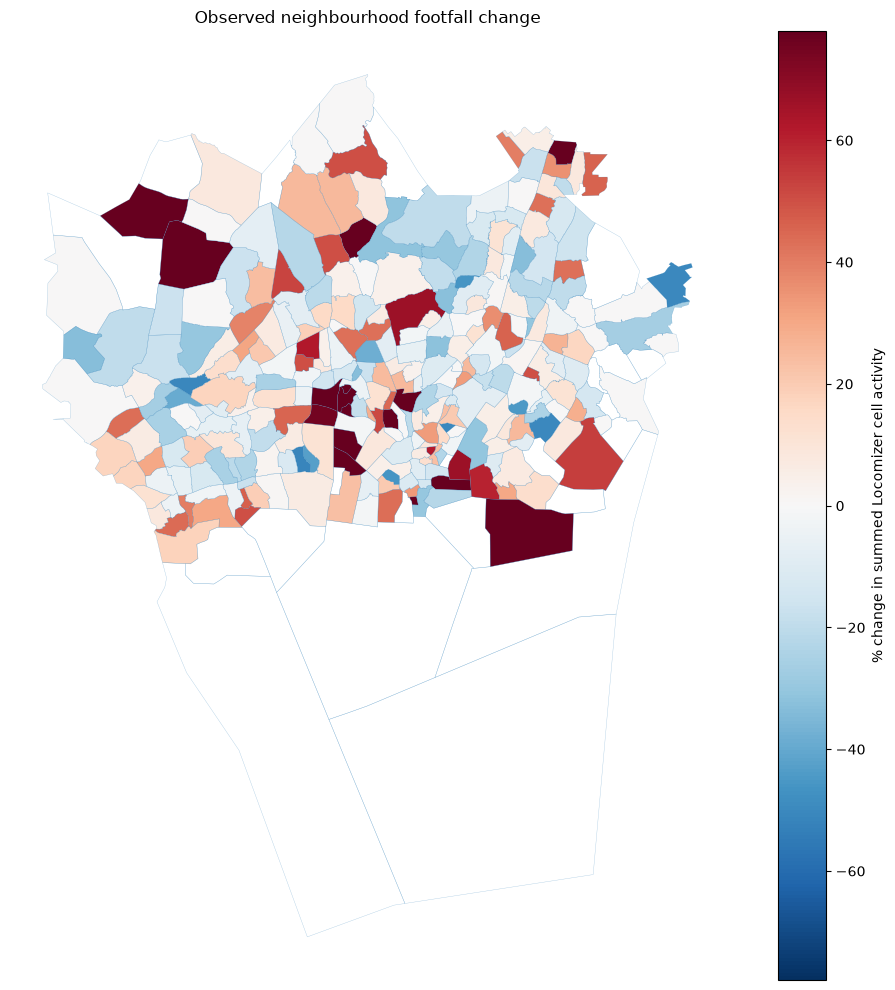

In [14]:
map_data = integrated_gdf.dropna(
    subset=["footfall_sum_pct_change"]
).copy()

if len(map_data) > 0:
    limit = np.nanpercentile(
        np.abs(
            map_data["footfall_sum_pct_change"]
        ),
        95,
    )

    if not np.isfinite(limit) or limit == 0:
        limit = 1

    fig, ax = plt.subplots(
        figsize=(11, 10)
    )

    integrated_gdf.boundary.plot(
        ax=ax,
        linewidth=0.25,
        alpha=0.4,
    )

    map_data.plot(
        ax=ax,
        column="footfall_sum_pct_change",
        cmap="RdBu_r",
        vmin=-limit,
        vmax=limit,
        legend=True,
        linewidth=0.2,
        legend_kwds={
            "label":
            "% change in summed Locomizer cell activity"
        },
    )

    ax.set_title(
        "Observed neighbourhood footfall change"
    )
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()


## 15. Map share of H3 cells with persistent/stable-or-increased activity

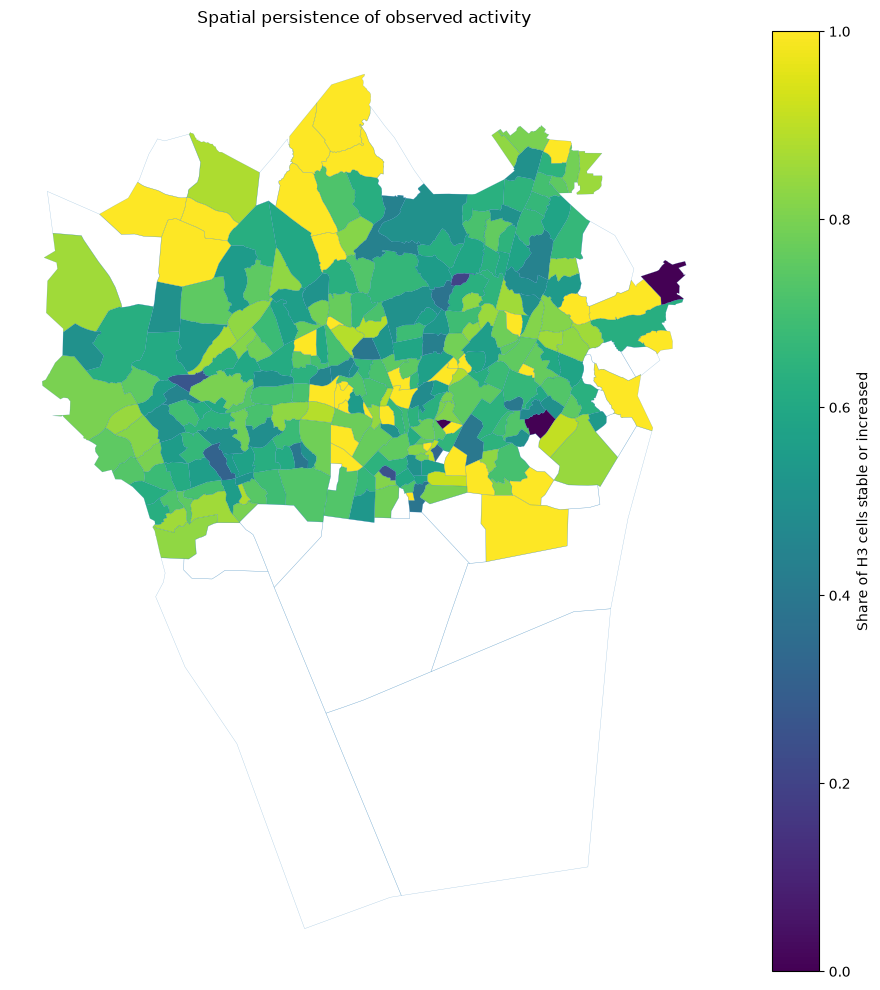

In [15]:
integrated_gdf[
    "share_cells_persistent"
] = (
    integrated_gdf[
        "share_cells_stable"
    ].fillna(0)
    + integrated_gdf[
        "share_cells_increased"
    ].fillna(0)
)

persistent_map = integrated_gdf.dropna(
    subset=["n_h3_cells"]
).copy()

fig, ax = plt.subplots(
    figsize=(11, 10)
)

integrated_gdf.boundary.plot(
    ax=ax,
    linewidth=0.25,
    alpha=0.4,
)

persistent_map.plot(
    ax=ax,
    column="share_cells_persistent",
    vmin=0,
    vmax=1,
    legend=True,
    linewidth=0.2,
    legend_kwds={
        "label":
        "Share of H3 cells stable or increased"
    },
)

ax.set_title(
    "Spatial persistence of observed activity"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


## 16. Map sampled cycling exposure-reduction potential

Only neighbourhoods represented in Stage 04 are coloured.

\[
PotentialExposureReduction =
PM_{2.5,fastest}
-
PM_{2.5,weighted}
\]

Positive values indicate that CAFEIN found a lower-PM₂.₅ cycling route to Otaniemi.


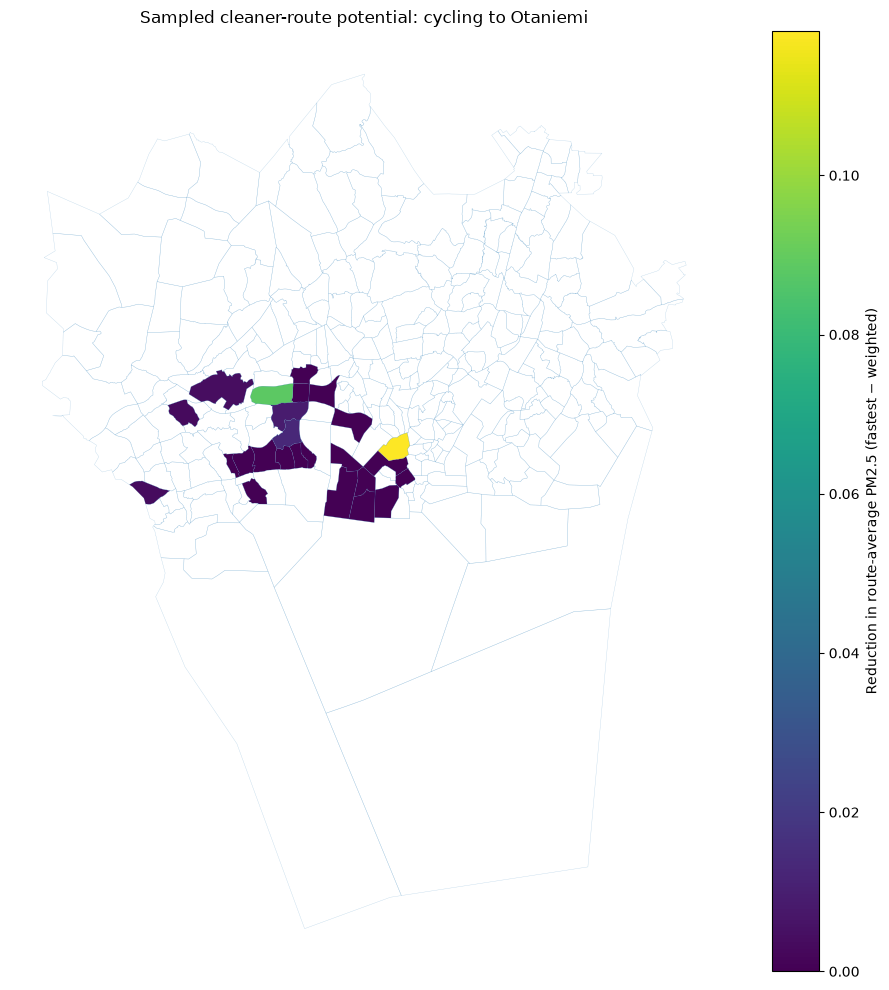

In [16]:
if (
    "bike_exposure_reduction_pm25"
    in integrated_gdf.columns
):
    bike_map = integrated_gdf.dropna(
        subset=[
            "bike_exposure_reduction_pm25"
        ]
    ).copy()

    if not bike_map.empty:
        fig, ax = plt.subplots(
            figsize=(11, 10)
        )

        integrated_gdf.boundary.plot(
            ax=ax,
            linewidth=0.25,
            alpha=0.3,
        )

        bike_map.plot(
            ax=ax,
            column="bike_exposure_reduction_pm25",
            legend=True,
            linewidth=0.5,
            legend_kwds={
                "label":
                "Reduction in route-average PM2.5 "
                "(fastest − weighted)"
            },
        )

        ax.set_title(
            "Sampled cleaner-route potential: "
            "cycling to Otaniemi"
        )
        ax.set_axis_off()

        plt.tight_layout()
        plt.show()
    else:
        print(
            "No Stage 04 route metrics available to map."
        )


## 17. Map additional cycling time required for the cleaner-route search

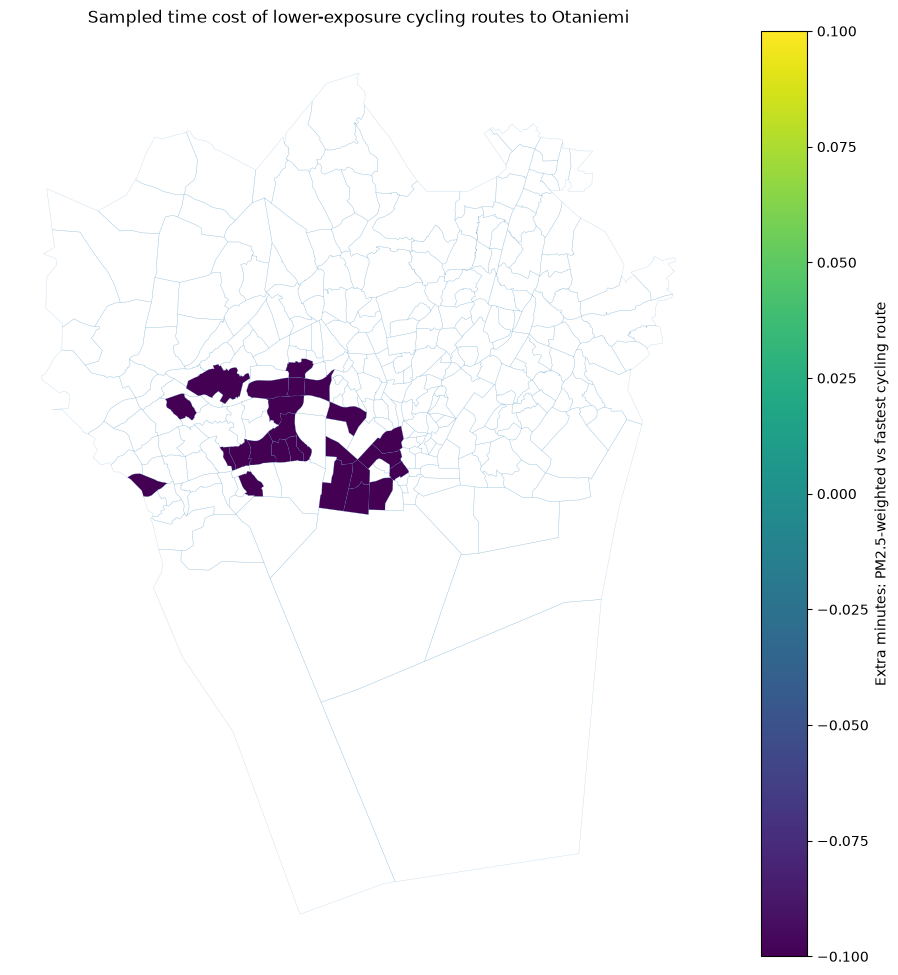

In [17]:
if "bike_extra_time_min" in integrated_gdf.columns:
    bike_time_map = integrated_gdf.dropna(
        subset=["bike_extra_time_min"]
    ).copy()

    if not bike_time_map.empty:
        fig, ax = plt.subplots(
            figsize=(11, 10)
        )

        integrated_gdf.boundary.plot(
            ax=ax,
            linewidth=0.25,
            alpha=0.3,
        )

        bike_time_map.plot(
            ax=ax,
            column="bike_extra_time_min",
            legend=True,
            linewidth=0.5,
            legend_kwds={
                "label":
                "Extra minutes: PM2.5-weighted "
                "vs fastest cycling route"
            },
        )

        ax.set_title(
            "Sampled time cost of lower-exposure "
            "cycling routes to Otaniemi"
        )
        ax.set_axis_off()

        plt.tight_layout()
        plt.show()


## 18. Plot exposure reduction vs extra travel time

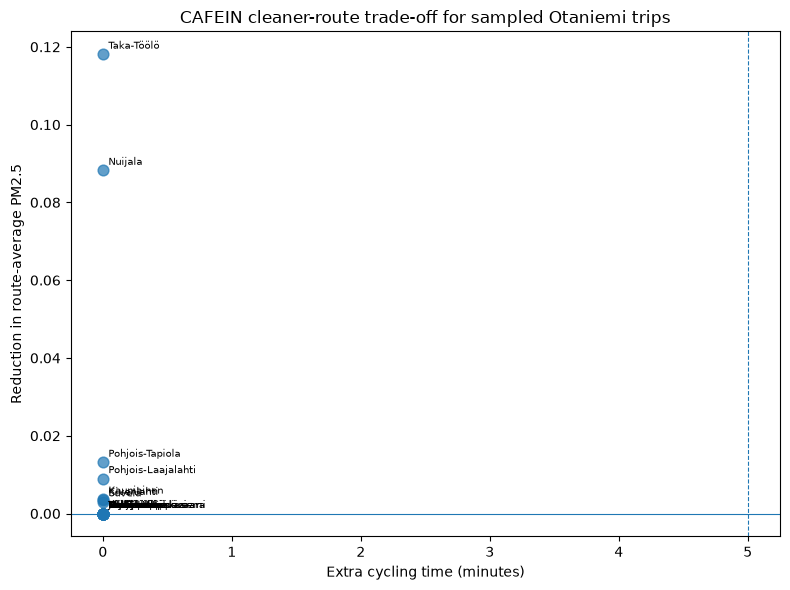

In [18]:
if {
    "bike_exposure_reduction_pm25",
    "bike_extra_time_min",
}.issubset(integrated.columns):

    scatter = integrated.dropna(
        subset=[
            "bike_exposure_reduction_pm25",
            "bike_extra_time_min",
        ]
    ).copy()

    if not scatter.empty:
        fig, ax = plt.subplots(
            figsize=(8, 6)
        )

        ax.scatter(
            scatter["bike_extra_time_min"],
            scatter[
                "bike_exposure_reduction_pm25"
            ],
            s=60,
            alpha=0.7,
        )

        ax.axhline(
            0,
            linewidth=0.8,
        )
        ax.axvline(
            LOW_EXTRA_TIME_MIN,
            linewidth=0.8,
            linestyle="--",
        )

        ax.set_xlabel(
            "Extra cycling time (minutes)"
        )
        ax.set_ylabel(
            "Reduction in route-average PM2.5"
        )
        ax.set_title(
            "CAFEIN cleaner-route trade-off "
            "for sampled Otaniemi trips"
        )

        for _, row in scatter.iterrows():
            ax.annotate(
                row["Neighbourhood_name"],
                (
                    row["bike_extra_time_min"],
                    row[
                        "bike_exposure_reduction_pm25"
                    ],
                ),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=7,
            )

        plt.tight_layout()
        plt.show()


## 19. Relationship between observed footfall response and cleaner-route time cost

This is exploratory because Stage 04 only represents a selected cycling destination.

It asks whether sampled origin neighbourhoods with more persistent observed activity also faced greater time costs for the cleaner cycling option.


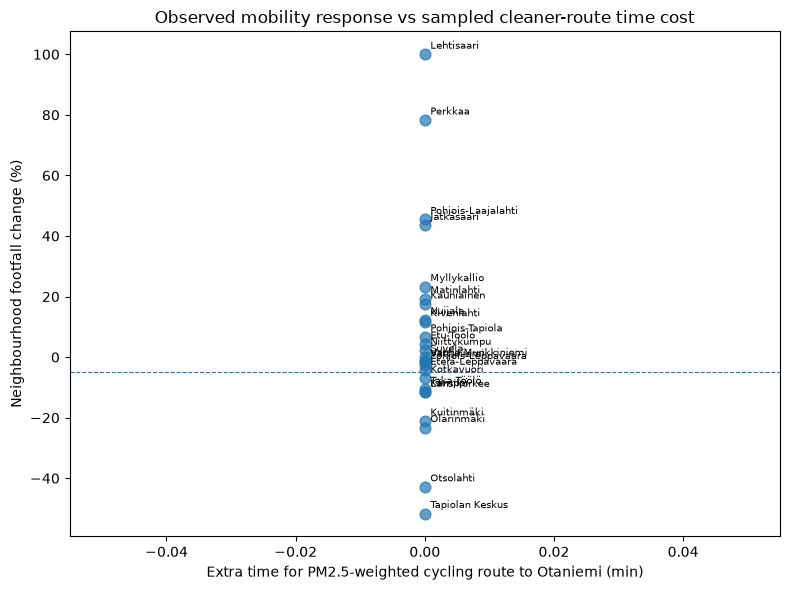

In [19]:
if {
    "footfall_sum_pct_change",
    "bike_extra_time_min",
}.issubset(integrated.columns):

    relation = integrated.dropna(
        subset=[
            "footfall_sum_pct_change",
            "bike_extra_time_min",
        ]
    ).copy()

    if not relation.empty:
        fig, ax = plt.subplots(
            figsize=(8, 6)
        )

        ax.scatter(
            relation["bike_extra_time_min"],
            relation[
                "footfall_sum_pct_change"
            ],
            s=60,
            alpha=0.7,
        )

        ax.axhline(
            -FOOTFALL_STABLE_THRESHOLD_PCT,
            linewidth=0.8,
            linestyle="--",
        )

        ax.set_xlabel(
            "Extra time for PM2.5-weighted "
            "cycling route to Otaniemi (min)"
        )
        ax.set_ylabel(
            "Neighbourhood footfall change (%)"
        )

        ax.set_title(
            "Observed mobility response vs sampled "
            "cleaner-route time cost"
        )

        for _, row in relation.iterrows():
            ax.annotate(
                row["Neighbourhood_name"],
                (
                    row["bike_extra_time_min"],
                    row[
                        "footfall_sum_pct_change"
                    ],
                ),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=7,
            )

        plt.tight_layout()
        plt.show()


## 20. Check whether the Stage 05 event pair is a strong PM₂.₅ contrast

Stage 00 ranks same-clock-hour pairs by absolute regional-median PM₂.₅ difference.

This cell displays the strongest alternatives and compares them with the event context carried forward from Stage 05.

If the selected Stage 05 pair has **negative** `regional_delta_pm25_median`, do not interpret Stage 06 as a smoke-worsening / forced-exposure event. Instead rerun Stage 05 with a stronger PM₂.₅-worsening pair and then rerun this notebook.


In [20]:
current_delta = (
    integrated[
        "regional_delta_pm25_median"
    ]
    .dropna()
    .iloc[0]
    if integrated[
        "regional_delta_pm25_median"
    ].notna().any()
    else np.nan
)

print(
    "Current Stage 05 regional ΔPM2.5:",
    current_delta,
    "µg/m³",
)

if pd.notna(current_delta):
    if current_delta > 0:
        print(
            "PM2.5 worsened in the selected pair: "
            "constraint interpretation is directionally applicable."
        )
    elif current_delta < 0:
        print(
            "WARNING: PM2.5 improved in the selected pair. "
            "Do not interpret persistence as forced exposure."
        )
    else:
        print(
            "PM2.5 was unchanged in the selected pair."
        )

if PM25_CANDIDATE_PAIRS.exists():
    candidate_pairs = pd.read_csv(
        PM25_CANDIDATE_PAIRS,
        parse_dates=[
            "time_A",
            "time_B",
        ],
    )

    worsening_pairs = (
        candidate_pairs.loc[
            candidate_pairs["delta_pm25"] > 0
        ]
        .sort_values(
            "delta_pm25",
            ascending=False,
        )
    )

    print()
    print(
        "Strongest same-hour PM2.5-worsening "
        "candidate pairs from Stage 00:"
    )

    display(
        worsening_pairs.head(15)
    )
else:
    print(
        "Stage 00 candidate-pairs file not found."
    )


Current Stage 05 regional ΔPM2.5: -2.8499999999999996 µg/m³

Strongest same-hour PM2.5-worsening candidate pairs from Stage 00:


,hour,time_A,time_B,pm25_A_median,pm25_B_median,delta_pm25,abs_delta_pm25,n_stations_A,n_stations_B


## 21. Priority table for follow-up

For neighbourhoods with a Stage 04 cycling sample, this table prioritizes combinations of:

- observed activity persistence;
- PM₂.₅ event direction;
- exposure reduction available from the sampled cleaner route;
- additional travel-time cost.

It is an exploratory screening table rather than a validated vulnerability index.


In [21]:
priority_columns = [
    "unit_id",
    "Neighbourhood_name",
    "Municipality_name",
    "n_h3_cells",
    "footfall_sum_pct_change",
    "share_cells_persistent",
    "regional_delta_pm25_median",
    "walk_sample_route_pm25",
    "walk_sample_pm25_time_burden",
    "pm25_mean_fastest",
    "pm25_mean_exposure_weighted",
    "bike_exposure_reduction_pm25",
    "bike_extra_time_min",
    "bike_exposure_reduction_per_extra_min",
    "provisional_constraint_class",
]

priority_columns = [
    c for c in priority_columns
    if c in integrated_gdf.columns
]

priority = (
    integrated_gdf[
        priority_columns
    ]
    .drop(
        columns="geometry",
        errors="ignore",
    )
    .copy()
)

if "has_bike_otaniemi_sample" in integrated.columns:
    sampled_ids = set(
        integrated.loc[
            integrated[
                "has_bike_otaniemi_sample"
            ],
            "unit_id",
        ].dropna()
    )

    priority = priority.loc[
        priority["unit_id"].isin(
            sampled_ids
        )
    ]

if "bike_extra_time_min" in priority.columns:
    priority = priority.sort_values(
        [
            "footfall_sum_pct_change",
            "bike_extra_time_min",
        ],
        ascending=[
            False,
            False,
        ],
    )

display(priority.head(30))


,unit_id,Neighbourhood_name,Municipality_name,n_h3_cells,footfall_sum_pct_change,share_cells_persistent,regional_delta_pm25_median,walk_sample_route_pm25,walk_sample_pm25_time_burden,pm25_mean_fastest,pm25_mean_exposure_weighted,bike_exposure_reduction_pm25,bike_extra_time_min,bike_exposure_reduction_per_extra_min,provisional_constraint_class
115,912202303,Lehtisaari,Helsinki,1.0,100.000000,1.000000,-2.85,NaN,NaN,2.711935,2.711935,0.000000,0.0,NaN,PM2.5 did not worsen in selected pair
7,491011118,Perkkaa,Espoo,14.0,78.260870,1.000000,-2.85,NaN,NaN,3.267414,3.267414,0.000000,0.0,NaN,PM2.5 did not worsen in selected pair
28,492025252,Pohjois-Laajalahti,Espoo,36.0,45.454545,0.833333,-2.85,NaN,NaN,2.891977,2.883009,0.008968,0.0,NaN,PM2.5 did not worsen in selected pair
103,911103203,Jätkäsaari,Helsinki,23.0,43.478261,0.782609,-2.85,2.744701,101.553924,2.736226,2.736226,0.000000,0.0,NaN,PM2.5 did not worsen in selected pair
107,911105313,Myllykallio,Helsinki,22.0,23.255814,0.727273,-2.85,NaN,NaN,2.806658,2.806658,0.000000,0.0,NaN,PM2.5 did not worsen in selected pair
31,493031313,Matinlahti,Espoo,23.0,19.230769,0.739130,-2.85,NaN,NaN,3.061459,3.061459,0.000000,0.0,NaN,PM2.5 did not worsen in selected pair
297,2351003006,Kauniainen,Kauniainen,65.0,17.518248,0.800000,-2.85,NaN,NaN,2.938757,2.935053,0.003704,0.0,NaN,PM2.5 did not worsen in selected pair
8,491013131,Nuijala,Espoo,34.0,12.345679,0.705882,-2.85,NaN,NaN,2.947587,2.859363,0.088224,0.0,NaN,PM2.5 did not worsen in selected pair
42,494041413,Kivenlahti,Espoo,29.0,11.666667,0.620690,-2.85,NaN,NaN,2.898607,2.895246,0.003361,0.0,NaN,PM2.5 did not worsen in selected pair
21,492021215,Pohjois-Tapiola,Espoo,28.0,6.666667,0.678571,-2.85,NaN,NaN,2.936266,2.923105,0.013161,0.0,NaN,PM2.5 did not worsen in selected pair


## 22. Save integrated outputs

In [22]:
table_csv = (
    OUTPUT_DIR
    / "stage06_neighbourhood_integration.csv"
)

gpkg_path = (
    OUTPUT_DIR
    / "stage06_neighbourhood_integration.gpkg"
)

priority_csv = (
    OUTPUT_DIR
    / "stage06_priority_sampled_neighbourhoods.csv"
)

h3_assignment_csv = (
    OUTPUT_DIR
    / "stage06_h3_to_neighbourhood_assignment.csv"
)

integrated.to_csv(
    table_csv,
    index=False,
)

integrated_gdf.to_file(
    gpkg_path,
    layer="neighbourhood_integration",
    driver="GPKG",
)

priority.to_csv(
    priority_csv,
    index=False,
)

matched_h3.drop(
    columns="geometry",
    errors="ignore",
).to_csv(
    h3_assignment_csv,
    index=False,
)

print("Saved:")
for path in [
    table_csv,
    gpkg_path,
    priority_csv,
    h3_assignment_csv,
]:
    print(" -", path)


Saved:
 - ../outputs/v3/06_neighbourhood_integration/stage06_neighbourhood_integration.csv
 - ../outputs/v3/06_neighbourhood_integration/stage06_neighbourhood_integration.gpkg
 - ../outputs/v3/06_neighbourhood_integration/stage06_priority_sampled_neighbourhoods.csv
 - ../outputs/v3/06_neighbourhood_integration/stage06_h3_to_neighbourhood_assignment.csv


# Interpretation guide

## What Stage 06 can now show

For each neighbourhood represented in the Locomizer observations, we can describe:

- how summed observed activity changed;
- whether that response was spatially consistent across its H3 cells;
- whether regional station PM₂.₅ worsened or improved;
- whether the neighbourhood appears in the sampled CAFEIN walking OD routes;
- whether the sampled cycling trip to Otaniemi had a lower-exposure alternative;
- how many additional minutes that alternative required.

## Strongest exploratory pattern

The combination of greatest interest is:

\[
PM_{2.5}\uparrow
+
Activity\ persists
+
Cleaner\ route\ costly/unavailable
\]

This is a **candidate constrained-exposure signal**, not yet proof of forced exposure.

## What should come after Stage 06

A stronger Stage 07 would scale beyond a two-time demonstration:

1. use the full Locomizer period;
2. derive matched same-hour / same-weekday baselines;
3. model footfall anomalies across all available hours;
4. use repeated PM₂.₅ station conditions rather than only one pair;
5. add transport-poverty / socioeconomic attributes;
6. ultimately replace regional station context with spatial historical PM₂.₅ surfaces when available.

That would move the project from proof of concept toward a publishable neighbourhood-level climate-mobility-equity analysis.
